In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, matthews_corrcoef
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
filename = "/content/Python_LongMethodSmell_Dataset.csv"
df = pd.read_csv(filename)

print("Shape:", df.shape)
df.head()

Shape: (894, 20)


,loc,lloc,scloc,comments,single_comments,multi_comments,blanks,h1,h2,n1,n2,vocabulary,length,calculated_length,volume,difficulty,effort,time,bugs,Experince Based
0,235,131,136,9,9,60,30,7,35,21,41,42,62,199.176390,334.323680,4.100000,1370.727089,76.151505,0.111441,1
1,162,64,67,20,20,49,26,9,28,19,38,37,57,163.135263,296.938842,6.107143,1813.447927,100.747107,0.098980,1
2,56,49,47,2,1,0,8,7,27,20,37,34,57,148.033447,289.985382,4.796296,1390.855813,77.269767,0.096662,1
3,49,23,45,3,3,0,1,1,3,2,4,4,6,4.754888,12.000000,0.666667,8.000000,0.444444,0.004000,1
4,166,128,119,23,23,0,24,15,76,58,109,91,167,533.445850,1086.801705,10.756579,11690.268340,649.459352,0.362267,1


In [3]:
label_col=df.columns[-1]
print(df[label_col].value_counts(dropna=False))

Experince Based 
0    685
1    209
Name: count, dtype: int64


In [4]:
print("Shape:", df.shape)
print("\nLabel distribution:")
print(df[label_col].value_counts())
print("\nLabel distribution (percent):")
print(df[label_col].value_counts(normalize=True).round(4))

print("\nAny missing values per column:")
print(df.isna().sum().sort_values(ascending=False).head(10))

Shape: (894, 20)

Label distribution:
Experince Based 
0    685
1    209
Name: count, dtype: int64

Label distribution (percent):
Experince Based 
0    0.7662
1    0.2338
Name: proportion, dtype: float64

Any missing values per column:
loc                0
lloc               0
scloc              0
comments           0
single_comments    0
multi_comments     0
blanks             0
h1                 0
h2                 0
n1                 0
dtype: int64


In [5]:
X = df.drop(columns=[label_col])
y = df[label_col]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (894, 19)
Target shape: (894,)


Baseline

In [6]:
baseline_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "mcc": make_scorer(matthews_corrcoef)
}

cv_results = cross_validate(
    baseline_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

baseline_summary = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "mcc"],
    "mean": [
        np.mean(cv_results["test_accuracy"]),
        np.mean(cv_results["test_precision"]),
        np.mean(cv_results["test_recall"]),
        np.mean(cv_results["test_f1"]),
        np.mean(cv_results["test_mcc"])
    ],
    "std": [
        np.std(cv_results["test_accuracy"]),
        np.std(cv_results["test_precision"]),
        np.std(cv_results["test_recall"]),
        np.std(cv_results["test_f1"]),
        np.std(cv_results["test_mcc"])
    ]
})

print("Baseline Logistic Regression - Cross-Validation Results")
display(baseline_summary)

Baseline Logistic Regression - Cross-Validation Results


,metric,mean,std
0,accuracy,0.911638,0.010201
1,precision,0.864651,0.042155
2,recall,0.741580,0.043857
3,f1,0.796652,0.024051
4,mcc,0.745533,0.028594


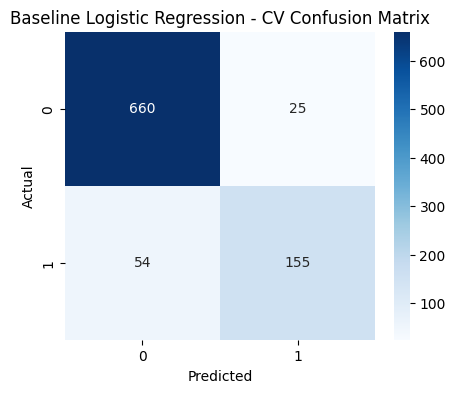

In [7]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_cv = cross_val_predict(
    baseline_model,
    X,
    y,
    cv=cv
)

cm = confusion_matrix(y, y_pred_cv)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline Logistic Regression - CV Confusion Matrix")
plt.show()

In [8]:
baseline_summary.to_csv("baseline_logistic_cv_results.csv", index=False)

# Optional: also save fold-wise scores
fold_results = pd.DataFrame({
    "fold": list(range(1, 6)),
    "accuracy": cv_results["test_accuracy"],
    "precision": cv_results["test_precision"],
    "recall": cv_results["test_recall"],
    "f1": cv_results["test_f1"],
    "mcc": cv_results["test_mcc"]
})

fold_results.to_csv("baseline_logistic_cv_fold_results.csv", index=False)

print("Saved:")
print("- baseline_logistic_cv_results.csv")
print("- baseline_logistic_cv_fold_results.csv")

Saved:
- baseline_logistic_cv_results.csv
- baseline_logistic_cv_fold_results.csv


TOOL

In [9]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    confusion_matrix
)

In [10]:
improved_model = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler()),
    ("feature_selection", SelectKBest(score_func=chi2, k=10)),
    ("smote", SMOTE(random_state=42)),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "mcc": make_scorer(matthews_corrcoef)
}

def eval_model(name, model):
    res = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)
    return {
        "model": name,
        "accuracy": np.mean(res["test_accuracy"]),
        "precision": np.mean(res["test_precision"]),
        "recall": np.mean(res["test_recall"]),
        "f1": np.mean(res["test_f1"]),
        "mcc": np.mean(res["test_mcc"]),
        "acc_std": np.std(res["test_accuracy"]),
        "f1_std": np.std(res["test_f1"]),
        "mcc_std": np.std(res["test_mcc"]),
    }

models = []

# 1) Baseline logistic
models.append((
    "Logistic",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000))
    ])
))

# 2) Logistic with class weight
models.append((
    "Logistic balanced",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ])
))

# 3) Logistic + MinMax + Chi2
models.append((
    "Logistic + MinMax + Chi2",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
        ("select", SelectKBest(score_func=chi2, k=10)),
        ("classifier", LogisticRegression(max_iter=2000))
    ])
))

# 4) Logistic + MinMax + Chi2 + SMOTE
models.append((
    "Logistic + MinMax + Chi2 + SMOTE",
    ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
        ("select", SelectKBest(score_func=chi2, k=10)),
        ("smote", SMOTE(random_state=42)),
        ("classifier", LogisticRegression(max_iter=2000))
    ])
))

# 5) GradientBoosting without SMOTE/selection
models.append((
    "GB no SMOTE no Chi2",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ])
))

# 6) GradientBoosting + Chi2
models.append((
    "GB + MinMax + Chi2",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
        ("select", SelectKBest(score_func=chi2, k=10)),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ])
))

# 7) GradientBoosting + Chi2 + SMOTE
models.append((
    "GB + MinMax + Chi2 + SMOTE",
    ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
        ("select", SelectKBest(score_func=chi2, k=10)),
        ("smote", SMOTE(random_state=42)),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ])
))

# 8) Random Forest balanced-ish
models.append((
    "Random Forest",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced_subsample"))
    ])
))

# 9) Extra Trees
models.append((
    "Extra Trees",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", ExtraTreesClassifier(n_estimators=400, random_state=42, class_weight="balanced"))
    ])
))

results = []
for name, model in models:
    results.append(eval_model(name, model))

results_df = pd.DataFrame(results).sort_values(by="mcc", ascending=False)
results_df

,model,accuracy,precision,recall,f1,mcc,acc_std,f1_std,mcc_std
7,Random Forest,0.956374,0.901235,0.913821,0.907306,0.878972,0.008945,0.019003,0.024811
4,GB no SMOTE no Chi2,0.951893,0.891177,0.904181,0.897503,0.866225,0.010410,0.023533,0.030312
8,Extra Trees,0.948547,0.922317,0.851568,0.885315,0.853514,0.013861,0.031712,0.040158
1,Logistic balanced,0.927286,0.803307,0.918699,0.856093,0.812008,0.015434,0.025914,0.033418
0,Logistic,0.911638,0.864651,0.741580,0.796652,0.745533,0.010201,0.024051,0.028594
5,GB + MinMax + Chi2,0.893717,0.812150,0.712660,0.756617,0.693418,0.028569,0.068682,0.084890
6,GB + MinMax + Chi2 + SMOTE,0.878005,0.722801,0.798839,0.756715,0.679251,0.050895,0.095531,0.127114
3,Logistic + MinMax + Chi2 + SMOTE,0.853462,0.662456,0.774913,0.713587,0.620095,0.037647,0.065976,0.089120
2,Logistic + MinMax + Chi2,0.864648,0.847560,0.511847,0.636929,0.587864,0.020759,0.062845,0.068967


In [12]:
k_values = [3, 5, 7, 10, 12, 15, 18]

chi2_results = []

for k in k_values:
    model = ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
        ("select", SelectKBest(score_func=chi2, k=k)),
        ("smote", SMOTE(random_state=42)),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ])

    res = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)
    chi2_results.append({
        "k": k,
        "accuracy": np.mean(res["test_accuracy"]),
        "precision": np.mean(res["test_precision"]),
        "recall": np.mean(res["test_recall"]),
        "f1": np.mean(res["test_f1"]),
        "mcc": np.mean(res["test_mcc"]),
    })

chi2_df = pd.DataFrame(chi2_results).sort_values("mcc", ascending=False)
chi2_df

,k,accuracy,precision,recall,f1,mcc
5,15,0.961967,0.896395,0.947503,0.920919,0.896791
6,18,0.958615,0.891501,0.937863,0.913730,0.887346
2,7,0.877999,0.727745,0.798839,0.758696,0.681484
3,10,0.878005,0.722801,0.798839,0.756715,0.679251
1,5,0.875764,0.714473,0.798839,0.752399,0.673579
4,12,0.874666,0.720005,0.779791,0.746237,0.666432
0,3,0.867924,0.693425,0.808479,0.743671,0.661920


In [13]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import chi2

X_filled = SimpleImputer(strategy="median").fit_transform(X)
X_scaled = MinMaxScaler().fit_transform(X_filled)

chi_scores, p_values = chi2(X_scaled, y)

feature_scores = pd.DataFrame({
    "feature": X.columns,
    "chi2_score": chi_scores,
    "p_value": p_values
}).sort_values(by="chi2_score", ascending=False)

feature_scores

,feature,chi2_score,p_value
7,h1,62.803178,2.284300e-15
15,difficulty,55.415607,9.755876e-14
9,n1,40.412667,2.056038e-10
12,length,39.461062,3.346666e-10
10,n2,38.972222,4.298789e-10
17,time,38.562513,5.302771e-10
16,effort,38.562513,5.302771e-10
18,bugs,34.731903,3.783798e-09
14,volume,34.731903,3.783798e-09
11,vocabulary,32.027089,1.520377e-08


In [14]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "mcc": make_scorer(matthews_corrcoef)
}

final_improved_model = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler()),
    ("feature_selection", SelectKBest(score_func=chi2, k=15)),
    ("smote", SMOTE(random_state=42)),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

final_results = cross_validate(
    final_improved_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

final_summary = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "mcc"],
    "mean": [
        np.mean(final_results["test_accuracy"]),
        np.mean(final_results["test_precision"]),
        np.mean(final_results["test_recall"]),
        np.mean(final_results["test_f1"]),
        np.mean(final_results["test_mcc"])
    ],
    "std": [
        np.std(final_results["test_accuracy"]),
        np.std(final_results["test_precision"]),
        np.std(final_results["test_recall"]),
        np.std(final_results["test_f1"]),
        np.std(final_results["test_mcc"])
    ]
})

display(final_summary)

,metric,mean,std
0,accuracy,0.961967,0.009617
1,precision,0.896395,0.025322
2,recall,0.947503,0.027648
3,f1,0.920919,0.019989
4,mcc,0.896791,0.026377


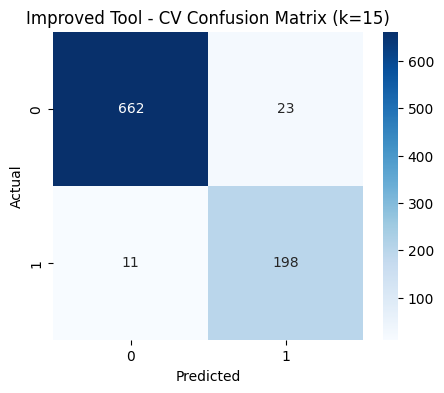

In [15]:
y_pred_cv = cross_val_predict(final_improved_model, X, y, cv=cv)

cm = confusion_matrix(y, y_pred_cv)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Improved Tool - CV Confusion Matrix (k=15)")
plt.show()

In [16]:
final_summary.to_csv("final_improved_k15_results.csv", index=False)

fold_results = pd.DataFrame({
    "fold": list(range(1, 6)),
    "accuracy": final_results["test_accuracy"],
    "precision": final_results["test_precision"],
    "recall": final_results["test_recall"],
    "f1": final_results["test_f1"],
    "mcc": final_results["test_mcc"]
})

fold_results.to_csv("final_improved_k15_fold_results.csv", index=False)

print("Saved final_improved_k15_results.csv")
print("Saved final_improved_k15_fold_results.csv")

Saved final_improved_k15_results.csv
Saved final_improved_k15_fold_results.csv


In [17]:
no_smote_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler()),
    ("feature_selection", SelectKBest(score_func=chi2, k=15)),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

no_smote_results = cross_validate(
    no_smote_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

no_smote_summary = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "mcc"],
    "mean": [
        np.mean(no_smote_results["test_accuracy"]),
        np.mean(no_smote_results["test_precision"]),
        np.mean(no_smote_results["test_recall"]),
        np.mean(no_smote_results["test_f1"]),
        np.mean(no_smote_results["test_mcc"])
    ],
    "std": [
        np.std(no_smote_results["test_accuracy"]),
        np.std(no_smote_results["test_precision"]),
        np.std(no_smote_results["test_recall"]),
        np.std(no_smote_results["test_f1"]),
        np.std(no_smote_results["test_mcc"])
    ]
})

display(no_smote_summary)

,metric,mean,std
0,accuracy,0.956374,0.010246
1,precision,0.900839,0.018248
2,recall,0.913937,0.032150
3,f1,0.907160,0.022705
4,mcc,0.878846,0.029356


In [18]:
comparison = baseline_summary.merge(
    final_summary,
    on="metric",
    suffixes=("_baseline", "_improved")
)

comparison["improvement"] = comparison["mean_improved"] - comparison["mean_baseline"]

comparison

,metric,mean_baseline,std_baseline,mean_improved,std_improved,improvement
0,accuracy,0.911638,0.010201,0.961967,0.009617,0.050330
1,precision,0.864651,0.042155,0.896395,0.025322,0.031744
2,recall,0.741580,0.043857,0.947503,0.027648,0.205923
3,f1,0.796652,0.024051,0.920919,0.019989,0.124267
4,mcc,0.745533,0.028594,0.896791,0.026377,0.151258


In [20]:
baseline_folds = pd.read_csv("baseline_logistic_cv_fold_results.csv")
improved_folds = pd.read_csv("final_improved_k15_fold_results.csv")

In [21]:
from scipy.stats import wilcoxon, ttest_rel

metrics = ["accuracy", "precision", "recall", "f1", "mcc"]

stats_rows = []

for metric in metrics:
    b = baseline_folds[metric].values
    i = improved_folds[metric].values

    # Paired t-test
    t_stat, p_t = ttest_rel(i, b)

    # Wilcoxon signed-rank test
    try:
        w_stat, p_w = wilcoxon(i, b, alternative="two-sided")
    except ValueError:
        w_stat, p_w = np.nan, np.nan

    stats_rows.append({
        "metric": metric,
        "baseline_mean": np.mean(b),
        "improved_mean": np.mean(i),
        "mean_difference": np.mean(i - b),
        "paired_t_stat": t_stat,
        "paired_t_pvalue": p_t,
        "wilcoxon_stat": w_stat,
        "wilcoxon_pvalue": p_w
    })

stats_df = pd.DataFrame(stats_rows)
stats_df

,metric,baseline_mean,improved_mean,mean_difference,paired_t_stat,paired_t_pvalue,wilcoxon_stat,wilcoxon_pvalue
0,accuracy,0.911638,0.961967,0.050330,11.673569,0.000308,0.0,0.0625
1,precision,0.864651,0.896395,0.031744,1.836207,0.140214,3.0,0.3125
2,recall,0.741580,0.947503,0.205923,6.452650,0.002969,0.0,0.0625
3,f1,0.796652,0.920919,0.124267,9.303898,0.000743,0.0,0.0625
4,mcc,0.745533,0.896791,0.151258,10.965052,0.000393,0.0,0.0625


In [22]:
baseline_summary = pd.read_csv("baseline_logistic_cv_results.csv")
improved_summary = pd.read_csv("final_improved_k15_results.csv")

comparison = baseline_summary.merge(
    improved_summary,
    on="metric",
    suffixes=("_baseline", "_improved")
).merge(
    stats_df[["metric", "mean_difference", "paired_t_pvalue", "wilcoxon_pvalue"]],
    on="metric"
)

comparison["improvement"] = comparison["mean_improved"] - comparison["mean_baseline"]

comparison

,metric,mean_baseline,std_baseline,mean_improved,std_improved,mean_difference,paired_t_pvalue,wilcoxon_pvalue,improvement
0,accuracy,0.911638,0.010201,0.961967,0.009617,0.050330,0.000308,0.0625,0.050330
1,precision,0.864651,0.042155,0.896395,0.025322,0.031744,0.140214,0.3125,0.031744
2,recall,0.741580,0.043857,0.947503,0.027648,0.205923,0.002969,0.0625,0.205923
3,f1,0.796652,0.024051,0.920919,0.019989,0.124267,0.000743,0.0625,0.124267
4,mcc,0.745533,0.028594,0.896791,0.026377,0.151258,0.000393,0.0625,0.151258


In [24]:
comparison.to_csv("final_comparison_table.csv", index=False)
stats_df.to_csv("statistical_tests.csv", index=False)

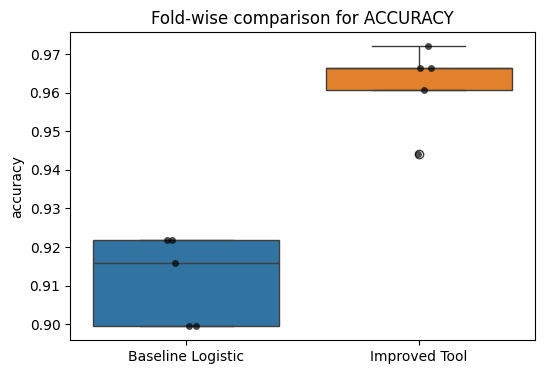

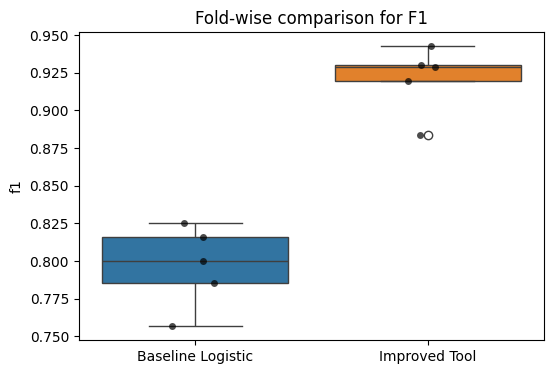

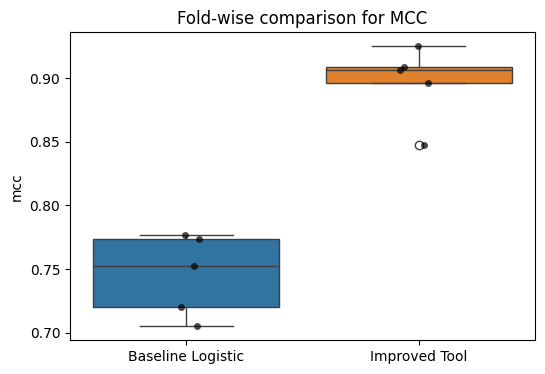

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

for metric in ["accuracy", "f1", "mcc"]:
    plt.figure(figsize=(6, 4))
    plot_df = pd.DataFrame({
        "Baseline Logistic": baseline_folds[metric],
        "Improved Tool": improved_folds[metric]
    })
    sns.boxplot(data=plot_df)
    sns.stripplot(data=plot_df, color="black", alpha=0.7)
    plt.title(f"Fold-wise comparison for {metric.upper()}")
    plt.ylabel(metric)
    plt.show()

In [26]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import GradientBoostingClassifier

final_tool = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler()),
    ("feature_selection", SelectKBest(score_func=chi2, k=15)),
    ("smote", SMOTE(random_state=42)),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

final_tool.fit(X, y)
print("Final tool trained on full dataset.")

Final tool trained on full dataset.


In [27]:
selected_mask = final_tool.named_steps["feature_selection"].get_support()
selected_features = X.columns[selected_mask]

importances = final_tool.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": selected_features,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_df

,feature,importance
1,scloc,0.929111
11,difficulty,0.021981
0,lloc,0.014908
2,comments,0.006570
3,h1,0.004723
14,bugs,0.004058
12,effort,0.003755
5,n1,0.003320
4,h2,0.003206
10,volume,0.002756


In [28]:
feature_importance_df.to_csv("final_feature_importance.csv", index=False)
print("Saved final_feature_importance.csv")

Saved final_feature_importance.csv


In [29]:
import joblib

joblib.dump(final_tool, "python_long_method_detector.joblib")
print("Saved python_long_method_detector.joblib")

Saved python_long_method_detector.joblib


In [30]:
def predict_long_method(sample_dict):
    """
    sample_dict should contain all feature columns used in X.
    Example:
    {
        'loc': 120,
        'lloc': 80,
        ...
    }
    """
    sample_df = pd.DataFrame([sample_dict])
    sample_df = sample_df[X.columns]

    pred = final_tool.predict(sample_df)[0]
    prob = final_tool.predict_proba(sample_df)[0, 1]

    return {
        "prediction": int(pred),
        "smell_probability": float(prob)
    }